# SVM Classifier - Phishing Site Detection

In this notebook I train a Support Vector Machine to detect phishing URLs. I use `LinearSVC` instead of the original SVC with RBF kernel because it is much faster on bigger datasets. I also increased the sample to 50,000 rows and added some extra URL features.

## 1. Import Libraries

In [1]:
import os
import re
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

## 2. Configuration

I put all the settings here so I can find and change them easily.

In [2]:
CONFIG = {
    "data_path":      "../preprocessing-dataset/processed_data.csv",
    "result_dir":     "result",
    "text_column":    "processed_text",
    "url_column":     "URL",
    "label_column":   "Label",
    "sample_size":    50_000,
    "test_size":      0.2,
    "random_state":   42,
    "svd_components": 200,
    "C":              1.0,
    "max_iter":       2000,
    "class_weight":   "balanced",
}

os.makedirs(CONFIG["result_dir"], exist_ok=True)
print("Result directory ready:", CONFIG["result_dir"])

Result directory ready: result


## 3. Load the Data

I load the processed CSV and take a stratified sample of 50,000 rows so the class ratio stays the same.

In [3]:
df = pd.read_csv(CONFIG["data_path"])
print(f"Full dataset shape: {df.shape}")

# Stratified sample via train_test_split — avoids pandas groupby column-dropping bugs
df, _ = train_test_split(
    df,
    train_size=CONFIG["sample_size"],
    stratify=df[CONFIG["label_column"]],
    random_state=CONFIG["random_state"],
)
df = df.reset_index(drop=True)

print(f"Sampled dataset shape: {df.shape}")
print(f"Label distribution:\n{df[CONFIG['label_column']].value_counts()}")
df.head()

Full dataset shape: (549346, 3)
Sampled dataset shape: (50000, 3)
Label distribution:
Label
good    35763
bad     14237
Name: count, dtype: int64


,URL,Label,processed_text
0,facebook.com/pages/Edan-Everly/113900548620801,good,facebook com page edan ever 113900548620801
1,pplumbing.us/file/outlook,bad,pplumb us file outlook
2,imdb.com/name/nm0559618/,good,imdb com name nm0559618
3,142.0.78.36/adeola/server/cp.php?m=login,bad,142 0 78 36 adeola server cp php m login
4,dannykimm.com/wp-content/uploads/2012/01/absa/...,bad,dannykimm com wp content upload 2012 01 absa n...


## 4. URL Features

I extract 6 simple features from each raw URL before splitting. These are things like the length of the URL, number of dots, number of digits, and whether it looks like an IP address.

In [4]:
_IP_RE = re.compile(r"\b(?:\d{1,3}\.){3}\d{1,3}\b")


def extract_url_features(url: str) -> list[float]:
    """Extract six handcrafted lexical features from a URL string.

    Args:
        url: Raw URL string.

    Returns:
        List of six numeric features: url_length, num_dots, num_digits,
        num_special, has_ip, subdomain_depth.
    """
    url = str(url)

    # Strip scheme to isolate hostname for subdomain depth
    hostname = re.sub(r"https?://", "", url).split("/")[0].split("?")[0]

    url_length     = len(url)
    num_dots       = url.count(".")
    num_digits     = sum(c.isdigit() for c in url)
    num_special    = sum(url.count(c) for c in ("@", "-", "_", "=", "?", "&"))
    has_ip         = int(bool(_IP_RE.search(url)))
    subdomain_depth = max(hostname.count(".") - 1, 0)

    return [url_length, num_dots, num_digits, num_special, has_ip, subdomain_depth]


url_feat_names = [
    "url_length", "num_dots", "num_digits",
    "num_special", "has_ip", "subdomain_depth",
]

url_features = np.array(
    df[CONFIG["url_column"]].apply(extract_url_features).tolist(),
    dtype=np.float32,
)

print(f"URL feature matrix shape: {url_features.shape}")
pd.DataFrame(url_features, columns=url_feat_names).describe()

URL feature matrix shape: (50000, 6)


,url_length,num_dots,num_digits,num_special,has_ip,subdomain_depth
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000
mean,50.738739,2.058540,4.729140,2.10822,0.014740,0.519940
std,43.251041,1.520999,11.327724,3.43475,0.120512,1.081159
min,7.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,29.000000,1.000000,0.000000,0.00000,0.000000,0.000000
50%,40.000000,2.000000,1.000000,1.00000,0.000000,0.000000
75%,59.000000,2.000000,6.000000,3.00000,0.000000,1.000000
max,1244.000000,35.000000,350.000000,61.00000,1.000000,25.000000


## 5. Split the Data

I do an 80/20 stratified split. I split on index so the text and URL feature arrays stay aligned.

In [5]:
y = df[CONFIG["label_column"]].values
text_all = df[CONFIG["text_column"]].fillna("").astype(str).values

# Split indices via a dummy array so text + url_features share the same split
idx = np.arange(len(df))
idx_train, idx_test = train_test_split(
    idx,
    test_size=CONFIG["test_size"],
    random_state=CONFIG["random_state"],
    stratify=y,
)

text_train, text_test         = text_all[idx_train], text_all[idx_test]
url_feat_train, url_feat_test = url_features[idx_train], url_features[idx_test]
y_train, y_test               = y[idx_train], y[idx_test]

print(f"Training samples: {len(idx_train)}")
print(f"Test samples:     {len(idx_test)}")

Training samples: 40000
Test samples:     10000


## 6. TF-IDF Vectorization

I fit a new `TfidfVectorizer` on the training text only and then transform the test set. This way the vocabulary is based only on training data.

In [6]:
tfidf = TfidfVectorizer()
x_train_tfidf = tfidf.fit_transform(text_train)
x_test_tfidf  = tfidf.transform(text_test)

print(f"TF-IDF vocab size:        {len(tfidf.vocabulary_)}")
print(f"Train TF-IDF shape: {x_train_tfidf.shape}")
print(f"Test  TF-IDF shape: {x_test_tfidf.shape}")

TF-IDF vocab size:        65976
Train TF-IDF shape: (40000, 65976)
Test  TF-IDF shape: (10000, 65976)


## 7. Reduce Dimensions with SVD

I use `TruncatedSVD` to reduce the TF-IDF matrix to 200 dimensions. I fit it on training data only.

In [7]:
svd = TruncatedSVD(n_components=CONFIG["svd_components"], random_state=CONFIG["random_state"])
x_train_svd = svd.fit_transform(x_train_tfidf)
x_test_svd  = svd.transform(x_test_tfidf)

print(f"SVD output dims: {x_train_svd.shape[1]}")
print(f"Explained variance ratio (cumulative): {svd.explained_variance_ratio_.sum():.4f}")

SVD output dims: 200
Explained variance ratio (cumulative): 0.1698


## 8. Combine the Features

I combine the 200 SVD columns with the 6 URL features using `np.hstack`. The final feature vector has 206 columns.

In [8]:
x_train = np.hstack([x_train_svd, url_feat_train])
x_test  = np.hstack([x_test_svd,  url_feat_test])

print(f"Combined train feature shape: {x_train.shape}")
print(f"Combined test  feature shape: {x_test.shape}")

Combined train feature shape: (40000, 206)
Combined test  feature shape: (10000, 206)


## 9. Train the Model

I use `LinearSVC` which is faster than the old RBF kernel SVM. I add `class_weight=balanced` to help with the imbalanced classes. I also wrap it in `CalibratedClassifierCV` so it can give probability scores.

In [9]:
base_svm = LinearSVC(
    C=CONFIG["C"],
    max_iter=CONFIG["max_iter"],
    class_weight=CONFIG["class_weight"],
    random_state=CONFIG["random_state"],
)

model = CalibratedClassifierCV(base_svm)
model.fit(x_train, y_train)
print("LinearSVC (calibrated) trained.")

LinearSVC (calibrated) trained.


## 10. Check the Results

I print the accuracy, classification report, and show the confusion matrix heatmap.

In [10]:
y_pred = model.predict(x_test)

acc = accuracy_score(y_test, y_pred)
print(f"LinearSVC — Test Accuracy: {acc:.4f}")

LinearSVC — Test Accuracy: 0.9037


In [11]:
report = classification_report(y_test, y_pred)
print("LinearSVC — Classification Report")
print(report)

LinearSVC — Classification Report
              precision    recall  f1-score   support

         bad       0.91      0.73      0.81      2847
        good       0.90      0.97      0.94      7153

    accuracy                           0.90     10000
   macro avg       0.91      0.85      0.87     10000
weighted avg       0.90      0.90      0.90     10000



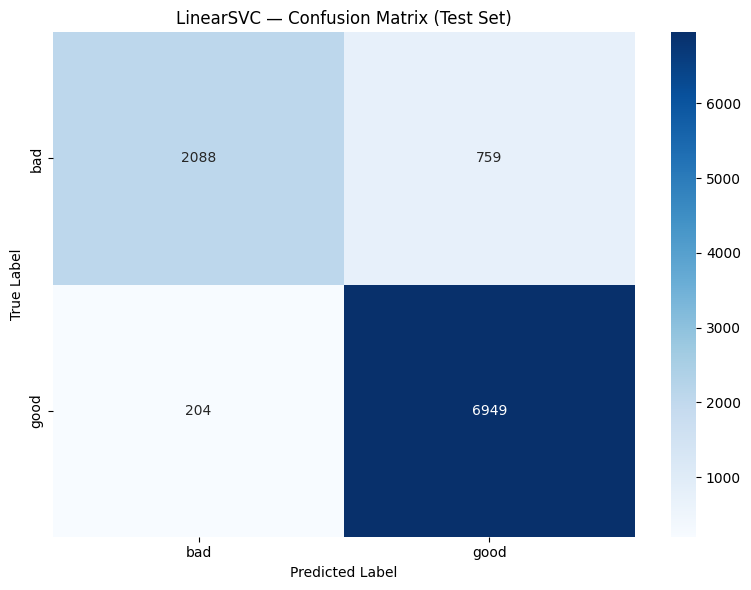

In [12]:
cm = confusion_matrix(y_test, y_pred)
labels = sorted(set(y))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=ax,
)
ax.set_title("LinearSVC — Confusion Matrix (Test Set)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

## 11. Save the Results

I save the model, classification report, and confusion matrix to the result folder.

In [13]:
model_path = os.path.join(CONFIG["result_dir"], "model_svm.pkl")
with open(model_path, "wb") as f:
    pickle.dump(model, f)
print(f"Model saved to {model_path}")

Model saved to result\model_svm.pkl


In [14]:
report_path = os.path.join(CONFIG["result_dir"], "classification_report_svm.txt")
with open(report_path, "w") as f:
    f.write(f"Test Accuracy: {acc:.4f}\n\n")
    f.write(report)
print(f"Classification report saved to {report_path}")

Classification report saved to result\classification_report_svm.txt


In [15]:
cm_path = os.path.join(CONFIG["result_dir"], "confusion_matrix_svm.png")
fig.savefig(cm_path, dpi=150, bbox_inches="tight")
print(f"Confusion matrix saved to {cm_path}")

Confusion matrix saved to result\confusion_matrix_svm.png
